# Phase 7 — Statistical Validation

## Objective

Exploratory Data Analysis helps identify potential relationships between variables, but visual observations alone are not sufficient to establish statistical significance.

The objective of this phase is to validate whether the selected and engineered features have a statistically significant relationship with the target variable (`Churn`).

The statistical techniques used in this phase include:

- Correlation Analysis
- Chi-Square Test of Independence
- One-Way ANOVA
- Mutual Information

These analyses provide quantitative evidence supporting the feature engineering decisions made in the previous phase and help justify the selection of features for model development.

## Part A — Correlation Analysis

Correlation analysis measures the strength and direction of the linear relationship between numerical features.

The objectives are to:

- Identify highly correlated numerical features.
- Detect potential multicollinearity.
- Examine how engineered features relate to existing numerical variables.

Since correlation only measures linear relationships, it will later be complemented with Mutual Information, which can capture non-linear dependencies.

In [ ]:
# ==========================================
# Import Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Load Feature-Engineered Dataset
# ==========================================
df = pd.read_csv("../data/processed/v1_feature_engineered_customer_churn.csv")

# ==========================================
# Separate Features and Target
# ==========================================
X = df.drop(columns="Churn")
y = df["Churn"]

print(df.shape)

In [1]:
# Step 1 — Select Numerical Features

# We don't want to compute a correlation matrix for all 31 features because most are one-hot encoded (0/1) columns, which would make the visualization noisy and less informative.

def get_numerical_features():
    """
    Return numerical features used for correlation analysis.
    """

    numerical_features = [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "TotalServices"
    ]

    print("=" * 60)
    print("NUMERICAL FEATURES")
    print("=" * 60)

    for feature in numerical_features:
        print(f"• {feature}")

    return numerical_features

In [2]:
numerical_features = get_numerical_features()

NUMERICAL FEATURES
• tenure
• MonthlyCharges
• TotalCharges
• TotalServices


### Step 2: Compute the Correlation Matrix

A correlation matrix provides a quantitative measure of the linear relationship between numerical features.

Correlation values range from **-1** to **1**:

- **+1** → Perfect positive relationship
- **0** → No linear relationship
- **−1** → Perfect negative relationship

The resulting matrix helps identify potential multicollinearity and validates relationships observed during exploratory data analysis.

In [5]:
import pandas as pd

df = pd.read_csv("../data/processed/v1_feature_engineered_customer_churn.csv")

print(df.shape)
df.head()

(7032, 32)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TotalServices,Churn
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,1,...,0,0,0,0,0,0,1,0,1,No
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,...,0,0,0,1,0,0,0,1,3,No
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,0,...,0,0,0,0,0,0,0,1,3,Yes
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,1,...,0,0,0,1,0,0,0,0,3,No
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,0,...,0,0,0,0,0,0,1,0,2,Yes


In [7]:
# Step 2 — Separate Features and Target

X = df.drop(columns="Churn")
y = df["Churn"]

print(f"Feature Matrix Shape : {X.shape}")
print(f"Target Shape         : {y.shape}")

Feature Matrix Shape : (7032, 31)
Target Shape         : (7032,)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_correlation_matrix(df, numerical_features):
    """
    Plot the correlation matrix for numerical features.
    """

    correlation_matrix = df[numerical_features].corr()

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        square=True
    )

    plt.title("Correlation Matrix")

    plt.tight_layout()

    plt.show()

    return correlation_matrix

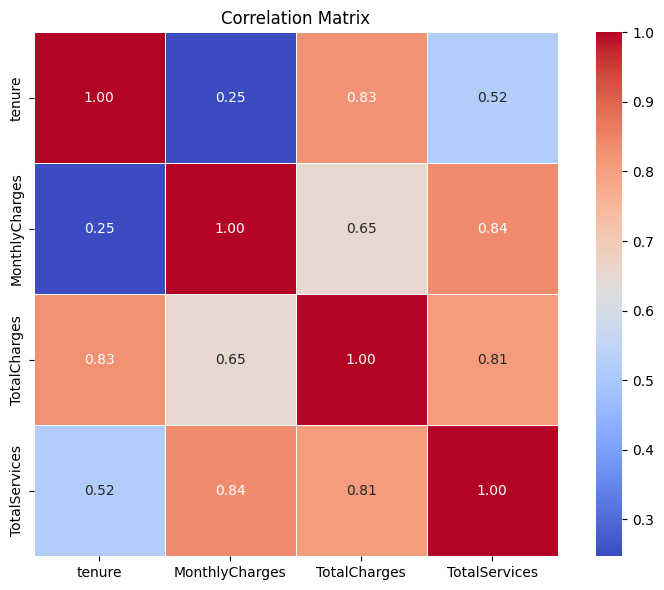

In [8]:
correlation_matrix = plot_correlation_matrix(
    X,
    numerical_features
)

### Step 3: Interpretation

The correlation matrix helps evaluate the strength and direction of linear relationships between numerical features.

Interpretation guidelines:

- Correlation close to **+1** indicates a strong positive relationship.
- Correlation close to **−1** indicates a strong negative relationship.
- Correlation close to **0** indicates little or no linear relationship.

The analysis focuses on identifying highly correlated features that may introduce redundancy or multicollinearity.

Since feature engineering already evaluated potential redundancy, this step serves as statistical validation rather than feature elimination.

In [9]:
def interpret_correlation_matrix(correlation_matrix):
    """
    Display the correlation matrix and identify highly correlated feature pairs.
    """

    print("=" * 70)
    print("CORRELATION MATRIX")
    print("=" * 70)

    print(correlation_matrix.round(3))

    print("\n" + "=" * 70)
    print("HIGH CORRELATION PAIRS (|r| ≥ 0.80)")
    print("=" * 70)

    found = False

    columns = correlation_matrix.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            corr = correlation_matrix.iloc[i, j]

            if abs(corr) >= 0.80:
                print(f"{columns[i]} ↔ {columns[j]} : {corr:.3f}")
                found = True

    if not found:
        print("No highly correlated feature pairs found.")

In [10]:
interpret_correlation_matrix(correlation_matrix)

CORRELATION MATRIX
                tenure  MonthlyCharges  TotalCharges  TotalServices
tenure           1.000           0.247         0.826          0.520
MonthlyCharges   0.247           1.000         0.651          0.838
TotalCharges     0.826           0.651         1.000          0.807
TotalServices    0.520           0.838         0.807          1.000

HIGH CORRELATION PAIRS (|r| ≥ 0.80)
tenure ↔ TotalCharges : 0.826
MonthlyCharges ↔ TotalServices : 0.838
TotalCharges ↔ TotalServices : 0.807


### Observation

The correlation analysis reveals several strong positive relationships among the numerical features.

**Key observations:**

- **tenure** and **TotalCharges** show a strong positive correlation (**r = 0.826**), indicating that customers with longer subscription durations generally accumulate higher total charges.

- **MonthlyCharges** and **TotalServices** exhibit a strong positive correlation (**r = 0.838**). Customers subscribing to more services tend to incur higher monthly charges.

- **TotalCharges** and **TotalServices** also demonstrate a strong positive correlation (**r = 0.807**), suggesting that customers with more subscribed services accumulate higher total charges over time.

Although these feature pairs are strongly correlated, each represents a distinct business concept:

- **tenure** measures customer longevity.
- **MonthlyCharges** reflects current billing.
- **TotalCharges** represents cumulative spending.
- **TotalServices** captures the breadth of subscribed services.

Therefore, no features are removed based solely on correlation analysis. The results validate previously observed relationships while confirming that each feature contributes meaningful business information.

## Part B — Chi-Square Test of Independence

The Chi-Square Test of Independence evaluates whether a categorical feature and the target variable are statistically associated.

### Hypotheses

- **Null Hypothesis (H₀):** The feature and customer churn are independent.
- **Alternative Hypothesis (H₁):** The feature and customer churn are associated.

A significance level of **α = 0.05** is used.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the feature has a statistically significant relationship with customer churn.

In [ ]:
# Step 1 — Import Required Library
from scipy.stats import chi2_contingency

In [12]:
# Step 2 — Identify Categorical Features
def get_categorical_features(df):
    """
    Return encoded categorical features for Chi-Square analysis.
    """

    categorical_features = [
        column
        for column in df.columns
        if column not in [
            "tenure",
            "MonthlyCharges",
            "TotalCharges",
            "TotalServices",
            "Churn"
        ]
    ]

    print("=" * 60)
    print("CATEGORICAL FEATURES")
    print("=" * 60)

    print(f"Total Features : {len(categorical_features)}\n")

    for feature in categorical_features:
        print(f"• {feature}")

    return categorical_features

In [13]:
categorical_features = get_categorical_features(df)

CATEGORICAL FEATURES
Total Features : 27

• gender
• SeniorCitizen
• Partner
• Dependents
• PhoneService
• PaperlessBilling
• MultipleLines_No phone service
• MultipleLines_Yes
• InternetService_Fiber optic
• InternetService_No
• OnlineSecurity_No internet service
• OnlineSecurity_Yes
• OnlineBackup_No internet service
• OnlineBackup_Yes
• DeviceProtection_No internet service
• DeviceProtection_Yes
• TechSupport_No internet service
• TechSupport_Yes
• StreamingTV_No internet service
• StreamingTV_Yes
• StreamingMovies_No internet service
• StreamingMovies_Yes
• Contract_One year
• Contract_Two year
• PaymentMethod_Credit card (automatic)
• PaymentMethod_Electronic check
• PaymentMethod_Mailed check


### Step 3: Perform Chi-Square Tests

The Chi-Square Test is applied to each encoded categorical feature to determine whether it has a statistically significant association with customer churn.

For each feature, the following statistics are reported:

- Chi-Square Statistic
- p-value
- Degrees of Freedom
- Statistical Decision

A feature is considered statistically significant if its p-value is less than the significance level (α = 0.05).

In [14]:
from scipy.stats import chi2_contingency
import pandas as pd


def perform_chi_square_tests(df, categorical_features, target="Churn"):
    """
    Perform Chi-Square Test of Independence for all categorical features.
    """

    results = []

    for feature in categorical_features:

        contingency_table = pd.crosstab(df[feature], df[target])

        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        results.append({
            "Feature": feature,
            "Chi-Square": round(chi2, 3),
            "p-value": p_value,
            "Decision": "Significant" if p_value < 0.05 else "Not Significant"
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="p-value",
        ascending=True
    ).reset_index(drop=True)

    return results_df

In [15]:
chi_square_results = perform_chi_square_tests(
    df,
    categorical_features
)

chi_square_results

,Feature,Chi-Square,p-value,Decision
0,InternetService_Fiber optic,663.356,2.782210e-146,Significant
1,Contract_Two year,637.848,9.815072e-141,Significant
2,PaymentMethod_Electronic check,637.589,1.117802e-140,Significant
3,OnlineBackup_No internet service,362.948,6.422521e-81,Significant
4,DeviceProtection_No internet service,362.948,6.422521e-81,Significant
5,StreamingMovies_No internet service,362.948,6.422521e-81,Significant
6,InternetService_No,362.948,6.422521e-81,Significant
7,OnlineSecurity_No internet service,362.948,6.422521e-81,Significant
8,TechSupport_No internet service,362.948,6.422521e-81,Significant
9,StreamingTV_No internet service,362.948,6.422521e-81,Significant


In [16]:
def summarize_chi_square_results(results_df):
    """
    Display a summary of Chi-Square test results.
    """

    total_features = len(results_df)

    significant = (results_df["Decision"] == "Significant").sum()

    not_significant = total_features - significant

    print("=" * 60)
    print("CHI-SQUARE TEST SUMMARY")
    print("=" * 60)

    print(f"Total Features        : {total_features}")
    print(f"Significant Features  : {significant}")
    print(f"Not Significant       : {not_significant}")

    print("\nTop 10 Most Significant Features\n")

    display(results_df.head(10))

In [17]:
summarize_chi_square_results(chi_square_results)

CHI-SQUARE TEST SUMMARY
Total Features        : 27
Significant Features  : 24
Not Significant       : 3

Top 10 Most Significant Features



,Feature,Chi-Square,p-value,Decision
0,InternetService_Fiber optic,663.356,2.782210e-146,Significant
1,Contract_Two year,637.848,9.815072e-141,Significant
2,PaymentMethod_Electronic check,637.589,1.117802e-140,Significant
3,OnlineBackup_No internet service,362.948,6.422521e-81,Significant
4,DeviceProtection_No internet service,362.948,6.422521e-81,Significant
5,StreamingMovies_No internet service,362.948,6.422521e-81,Significant
6,InternetService_No,362.948,6.422521e-81,Significant
7,OnlineSecurity_No internet service,362.948,6.422521e-81,Significant
8,TechSupport_No internet service,362.948,6.422521e-81,Significant
9,StreamingTV_No internet service,362.948,6.422521e-81,Significant


### Observation

The Chi-Square Test indicates that **24 out of 27 categorical features** have a statistically significant association with customer churn at the 5% significance level.

### Key Findings

- Internet-related services exhibit the strongest association with churn.
- Customers with **Fiber Optic Internet** show a highly significant relationship with churn.
- Contract type is one of the strongest predictors, particularly **Two-Year Contracts**, which are strongly associated with customer retention.
- Payment methods also influence churn, with **Electronic Check** showing a significant association.
- Service-related features such as Online Security, Tech Support, Device Protection, and Streaming Services demonstrate statistically significant relationships with churn.

Three features were found to be **not statistically significant**:

- Gender
- Phone Service
- Multiple Lines (No Phone Service)

These variables show no evidence of a statistical association with customer churn based on the Chi-Square Test.

Overall, the results provide strong statistical evidence that the majority of categorical features contribute meaningful information for churn prediction.

### Interview Insight

If asked:

"What did the Chi-Square Test tell you?"

You can answer:

The Chi-Square Test showed that 24 of the 27 categorical features were significantly associated with customer churn (p < 0.05). Features related to internet services, contract type, and payment method had the strongest associations. Only Gender, Phone Service, and Multiple Lines (No Phone Service) were not statistically significant.

This is concise, evidence-based, and demonstrates statistical reasoning.

## Part C — One-Way ANOVA

The One-Way Analysis of Variance (ANOVA) is used to determine whether the mean values of numerical features differ significantly between customers who churned and those who did not.

### Hypotheses

- **Null Hypothesis (H₀):** The mean of the numerical feature is the same for both churn groups.
- **Alternative Hypothesis (H₁):** The mean differs between the churn groups.

A significance level of **α = 0.05** is used.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating that the feature has a statistically significant relationship with customer churn.

In [19]:
# Step 1 — Import Required Library
from scipy.stats import f_oneway

In [20]:
# Step 2 — Select Numerical Features
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "TotalServices"
]

print(numerical_features)


['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices']


In [27]:
# Step 3 — Perform ANOVA



import pandas as pd
from scipy.stats import f_oneway


def perform_anova(df, numerical_features, target="Churn"):
    """
    Perform One-Way ANOVA for numerical features.
    """

    classes = df[target].unique()

    if len(classes) != 2:
        raise ValueError("Target variable must contain exactly two classes.")

    group1 = df[df[target] == classes[0]]
    group2 = df[df[target] == classes[1]]

    results = []

    for feature in numerical_features:

        f_statistic, p_value = f_oneway(
            group1[feature],
            group2[feature]
        )

        results.append({
            "Feature": feature,
            "F-Statistic": round(f_statistic, 3),
            "p-value": p_value,
            "Decision": "Significant" if p_value < 0.05 else "Not Significant"
        })

    results_df = (
        pd.DataFrame(results)
        .sort_values("p-value")
        .reset_index(drop=True)
    )

    return results_df



# import pandas as pd
# from scipy.stats import f_oneway


# def perform_anova(df, numerical_features, target="Churn"):
#     """
#     Perform One-Way ANOVA for numerical features.
#     """

#     results = []

#     for feature in numerical_features:

#         churn_yes = df[df[target] == 1][feature]
#         churn_no = df[df[target] == 0][feature]

#         f_statistic, p_value = f_oneway(churn_yes, churn_no)

#         results.append({
#             "Feature": feature,
#             "F-Statistic": round(f_statistic, 3),
#             "p-value": p_value,
#             "Decision": "Significant" if p_value < 0.05 else "Not Significant"
#         })

#     results_df = pd.DataFrame(results)

#     results_df = results_df.sort_values(
#         by="p-value"
#     ).reset_index(drop=True)

#     return results_df

In [28]:
anova_results = perform_anova(
    df,
    numerical_features
)

anova_results

,Feature,F-Statistic,p-value,Decision
0,tenure,1007.509,9.437650e-207,Significant
1,TotalCharges,291.345,4.876866e-64,Significant
2,MonthlyCharges,271.577,6.760843e-60,Significant
3,TotalServices,10.587,1.143949e-03,Significant


In [29]:
# Step 4 — Summary Function

def summarize_anova_results(results_df):
    """
    Display a summary of ANOVA results.
    """

    significant = (results_df["Decision"] == "Significant").sum()

    print("=" * 60)
    print("ANOVA SUMMARY")
    print("=" * 60)

    print(f"Total Numerical Features : {len(results_df)}")
    print(f"Significant Features     : {significant}")
    print(f"Not Significant          : {len(results_df)-significant}")

    print("\nResults\n")

    display(results_df)

In [30]:
summarize_anova_results(anova_results)

ANOVA SUMMARY
Total Numerical Features : 4
Significant Features     : 4
Not Significant          : 0

Results



,Feature,F-Statistic,p-value,Decision
0,tenure,1007.509,9.437650e-207,Significant
1,TotalCharges,291.345,4.876866e-64,Significant
2,MonthlyCharges,271.577,6.760843e-60,Significant
3,TotalServices,10.587,1.143949e-03,Significant


In [26]:
print(df["Churn"].value_counts())

print("\nUnique values:")
print(df["Churn"].unique())

print("\nData type:")
print(df["Churn"].dtype)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Unique values:
['No' 'Yes']

Data type:
object


### Observation

The One-Way ANOVA results indicate that **all numerical features have a statistically significant relationship with customer churn** at the 5% significance level.

### Key Findings

- **tenure** has the highest F-statistic, indicating the strongest difference in mean values between customers who churned and those who did not.
- **TotalCharges** and **MonthlyCharges** also exhibit highly significant differences across the churn groups.
- The engineered feature **TotalServices** is statistically significant, demonstrating that the number of subscribed services contributes meaningful information for churn prediction.

Since all numerical features have p-values less than 0.05, the null hypothesis is rejected for every feature.

These results provide statistical evidence that the selected numerical and engineered features are relevant predictors of customer churn and should be retained for model development.

### Interview Insight

If an interviewer asks:

"How did you validate your engineered feature?"

A strong response is:

I created the TotalServices feature to represent overall customer engagement. I then validated it using a One-Way ANOVA test, which showed a statistically significant difference in its mean values between churned and non-churned customers (p < 0.05). This confirmed that the engineered feature provides meaningful predictive information and should be retained.

This is much stronger than simply saying, "I thought it looked useful."

## Part D — Mutual Information

Mutual Information (MI) measures the amount of information that each feature provides about the target variable.

Unlike correlation, Mutual Information can identify both linear and non-linear relationships between variables.

Higher Mutual Information scores indicate that a feature provides more information for predicting customer churn.

The objective of this analysis is to rank the features according to their predictive relevance before model development.

In [31]:
# Step 1 — Import Library
from sklearn.feature_selection import mutual_info_classif

In [32]:
# Step 2 — Compute Mutual Information Scores
import pandas as pd
from sklearn.feature_selection import mutual_info_classif


def calculate_mutual_information(X, y):
    """
    Calculate Mutual Information scores for all features.
    """

    # Convert target to numeric if necessary
    if y.dtype == "object":
        y = y.map({
            "No": 0,
            "Yes": 1
        })

    mi_scores = mutual_info_classif(
        X,
        y,
        random_state=42
    )

    results = pd.DataFrame({
        "Feature": X.columns,
        "Mutual Information": mi_scores
    })

    results = results.sort_values(
        by="Mutual Information",
        ascending=False
    ).reset_index(drop=True)

    return results

In [33]:
mi_results = calculate_mutual_information(X, y)

mi_results

,Feature,Mutual Information
0,tenure,0.078611
1,PaymentMethod_Electronic check,0.051394
2,Contract_Two year,0.050600
3,MonthlyCharges,0.047275
4,InternetService_No,0.043711
5,InternetService_Fiber optic,0.042680
6,TotalCharges,0.042326
7,DeviceProtection_No internet service,0.038306
8,OnlineSecurity_No internet service,0.037142
9,StreamingMovies_No internet service,0.033664


In [34]:
# Step 3 — Visualize Feature Importance
import matplotlib.pyplot as plt


def plot_mutual_information(mi_results, top_n=15):
    """
    Plot the top Mutual Information scores.
    """

    top_features = mi_results.head(top_n)

    plt.figure(figsize=(10, 6))

    plt.barh(
        top_features["Feature"],
        top_features["Mutual Information"]
    )

    plt.gca().invert_yaxis()

    plt.title(f"Top {top_n} Features by Mutual Information")

    plt.xlabel("Mutual Information Score")

    plt.tight_layout()

    plt.show()

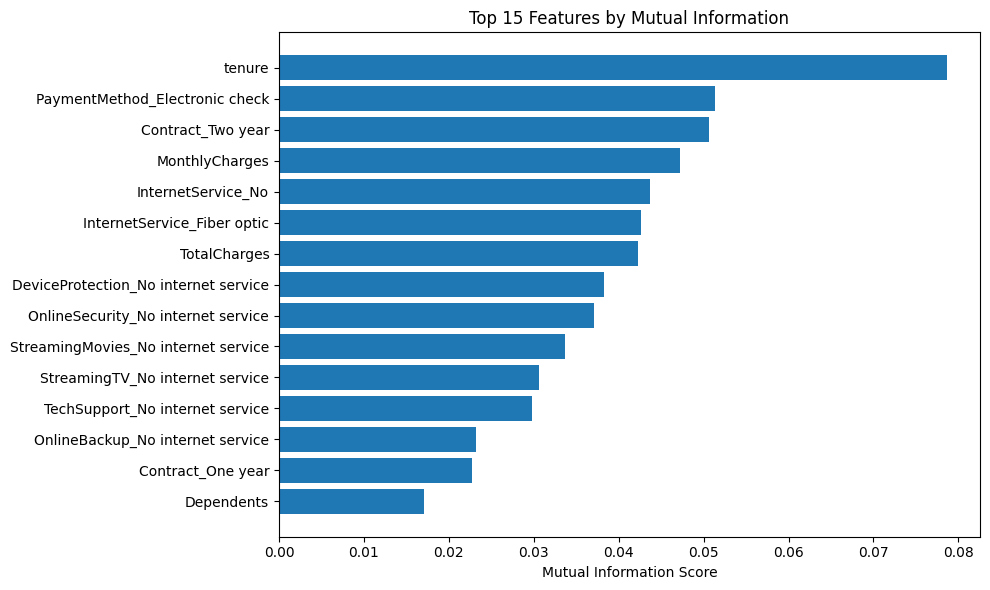

In [35]:
plot_mutual_information(mi_results)

In [36]:
# Step 4 — Summary Function
def summarize_mutual_information(mi_results, top_n=10):
    """
    Display the top Mutual Information features.
    """

    print("=" * 60)
    print("MUTUAL INFORMATION SUMMARY")
    print("=" * 60)

    print(f"Total Features : {len(mi_results)}")

    print(f"\nTop {top_n} Features\n")

    display(mi_results.head(top_n))

In [37]:
summarize_mutual_information(mi_results)

MUTUAL INFORMATION SUMMARY
Total Features : 31

Top 10 Features



,Feature,Mutual Information
0,tenure,0.078611
1,PaymentMethod_Electronic check,0.051394
2,Contract_Two year,0.050600
3,MonthlyCharges,0.047275
4,InternetService_No,0.043711
5,InternetService_Fiber optic,0.042680
6,TotalCharges,0.042326
7,DeviceProtection_No internet service,0.038306
8,OnlineSecurity_No internet service,0.037142
9,StreamingMovies_No internet service,0.033664


### Observation

Mutual Information ranks features according to the amount of information they provide about the target variable.

### Key Findings

- **tenure** is the most informative feature for predicting customer churn.
- **Payment Method (Electronic Check)** and **Contract Type (Two-Year Contract)** are among the strongest categorical predictors.
- **Monthly Charges** and **Total Charges** also provide substantial predictive information.
- Internet-related features consistently appear among the highest-ranked features, reinforcing their importance in churn prediction.
- The engineered feature **TotalServices** contributes predictive information, although its importance is lower than several original business features.

Features with very low or zero Mutual Information, such as **StreamingTV_Yes** and **MultipleLines_No phone service**, contribute little additional predictive information individually.

Overall, the Mutual Information analysis confirms that the selected feature set contains several highly informative predictors suitable for model development.

# Statistical Validation Summary

The statistical validation phase was conducted to verify that the selected and engineered features have meaningful relationships with the target variable before model development.

## Summary

| Statistical Method | Objective | Result |
|--------------------|-----------|--------|
| Correlation Analysis | Examine relationships among numerical features | Strong but meaningful correlations observed |
| Chi-Square Test | Validate categorical features | 24 of 27 categorical features were statistically significant |
| One-Way ANOVA | Validate numerical features | All numerical features were statistically significant |
| Mutual Information | Rank predictive features | Identified the most informative predictors of churn |

## Conclusion

The statistical analyses provide strong evidence that the selected feature set is suitable for customer churn prediction.

No additional feature removal is necessary at this stage, and the validated dataset is ready for machine learning model development.

In [38]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df.to_csv(
    "../data/processed/v1_feature_engineered_customer_churn.csv",
    index=False
)